In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive

drive.mount('/content/drive')

base_path = (
    '/content/drive/MyDrive/'
    'dissertation_project/data'
)

processed_path = (
    f'{base_path}/processed'
)

print("Processed path:")
print(processed_path)

Mounted at /content/drive
Processed path:
/content/drive/MyDrive/dissertation_project/data/processed


In [3]:
# Load MAPIE results
results_file = (
    f'{processed_path}/'
    'mapie_conformal_results.csv'
)

mapie_results = pd.read_csv(
    results_file
)

display(
    mapie_results
)

,Method,Target,Confidence Level,Empirical Coverage,Average Prediction Set Size
0,Split Conformal,Pleural Effusion,0.9,0.902475,1.468705


In [4]:
# Overall coverage
confidence_level = float(
    mapie_results[
        'Confidence Level'
    ].iloc[0]
)

coverage = float(
    mapie_results[
        'Empirical Coverage'
    ].iloc[0]
)

set_size = float(
    mapie_results[
        'Average Prediction Set Size'
    ].iloc[0]
)

coverage_gap = (
    coverage - confidence_level
)

print(
    "Target confidence:",
    round(confidence_level, 4)
)

print(
    "Empirical coverage:",
    round(coverage, 4)
)

print(
    "Coverage gap:",
    round(coverage_gap, 4)
)

print(
    "Average prediction-set size:",
    round(set_size, 4)
)

Target confidence: 0.9
Empirical coverage: 0.9025
Coverage gap: 0.0025
Average prediction-set size: 1.4687


In [5]:
# efficiency measure
if set_size > 0:

    efficiency = (
        coverage / set_size
    )

else:

    efficiency = 0

print(
    "Prediction-set efficiency:",
    round(efficiency, 4)
)

Prediction-set efficiency: 0.6145


In [6]:
# Summary table
evaluation_summary = pd.DataFrame({

    'Method': [
        'Split Conformal'
    ],

    'Target': [
        mapie_results[
            'Target'
        ].iloc[0]
    ],

    'Target Confidence': [
        confidence_level
    ],

    'Empirical Coverage': [
        coverage
    ],

    'Coverage Gap': [
        coverage_gap
    ],

    'Average Set Size': [
        set_size
    ],

    'Efficiency': [
        efficiency
    ]
})

display(
    evaluation_summary
)

,Method,Target,Target Confidence,Empirical Coverage,Coverage Gap,Average Set Size,Efficiency
0,Split Conformal,Pleural Effusion,0.9,0.902475,0.002475,1.468705,0.61447


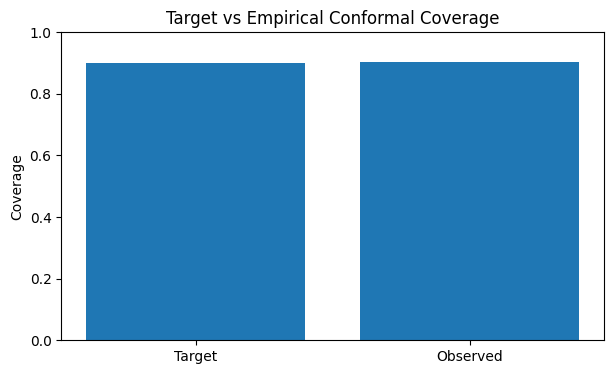

In [7]:
plt.figure(figsize=(7, 4))
plt.bar(['Target', 'Observed'],[confidence_level, coverage])
plt.ylim(0, 1)
plt.ylabel('Coverage')
plt.title('Target vs Empirical Conformal Coverage')
plt.show()

In [8]:
# Load patient information for subgroup check
csv_files = glob.glob(
    f'{processed_path}/*.csv'
)

candidate_files = []

for file in csv_files:

    name = os.path.basename(
        file
    ).lower()

    if (
        'heldout' in name
        or 'calibration' in name
        or '687' in name
        or 'test' in name
    ):

        candidate_files.append(
            file
        )

print(
    "Candidate files:"
)

for file in candidate_files:

    print(
        os.path.basename(file)
    )

Candidate files:
test_calibration_ids.csv
test_calibration_pool.csv
text_features_heldout.csv
image_features_heldout.csv
structured_features_mlp_heldout.csv
fusion_features_layer1_heldout.csv


In [9]:
evaluation_file = None

for file in candidate_files:

    name = os.path.basename(
        file
    ).lower()

    if 'heldout' in name:

        evaluation_file = file

        break

if evaluation_file is None:

    evaluation_file = candidate_files[0]

print(
    "Evaluation file:",
    evaluation_file
)

evaluation_df = pd.read_csv(
    evaluation_file
)

print(
    "Records:",
    len(evaluation_df)
)

Evaluation file: /content/drive/MyDrive/dissertation_project/data/processed/text_features_heldout.csv
Records: 687


In [10]:
print(
    "CONFORMAL PREDICTION EVALUATION"
)

print(
    "========================================"
)

print(
    "Target:",
    mapie_results[
        'Target'
    ].iloc[0]
)

print(
    "Confidence level:",
    confidence_level
)

print(
    "Empirical coverage:",
    round(
        coverage,
        4
    )
)

print(
    "Average prediction-set size:",
    round(
        set_size,
        4
    )
)

print(
    "Prediction-set efficiency:",
    round(
        efficiency,
        4
    )
)

if abs(coverage_gap) <= 0.05:

    print(
        "Coverage is close to the target level."
    )

else:

    print(
        "Coverage differs from the target level."
    )

CONFORMAL PREDICTION EVALUATION
Target: Pleural Effusion
Confidence level: 0.9
Empirical coverage: 0.9025
Average prediction-set size: 1.4687
Prediction-set efficiency: 0.6145
Coverage is close to the target level.
